## Imports

In [ ]:
!pip install pandas numpy scikit-learn optuna optuna-integration pygad
import pandas as pd
import numpy as np
import optuna
import time
import pygad
from optuna.integration import OptunaSearchCV
from optuna.exceptions import TrialPruned
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Lectura del conjunto de datos

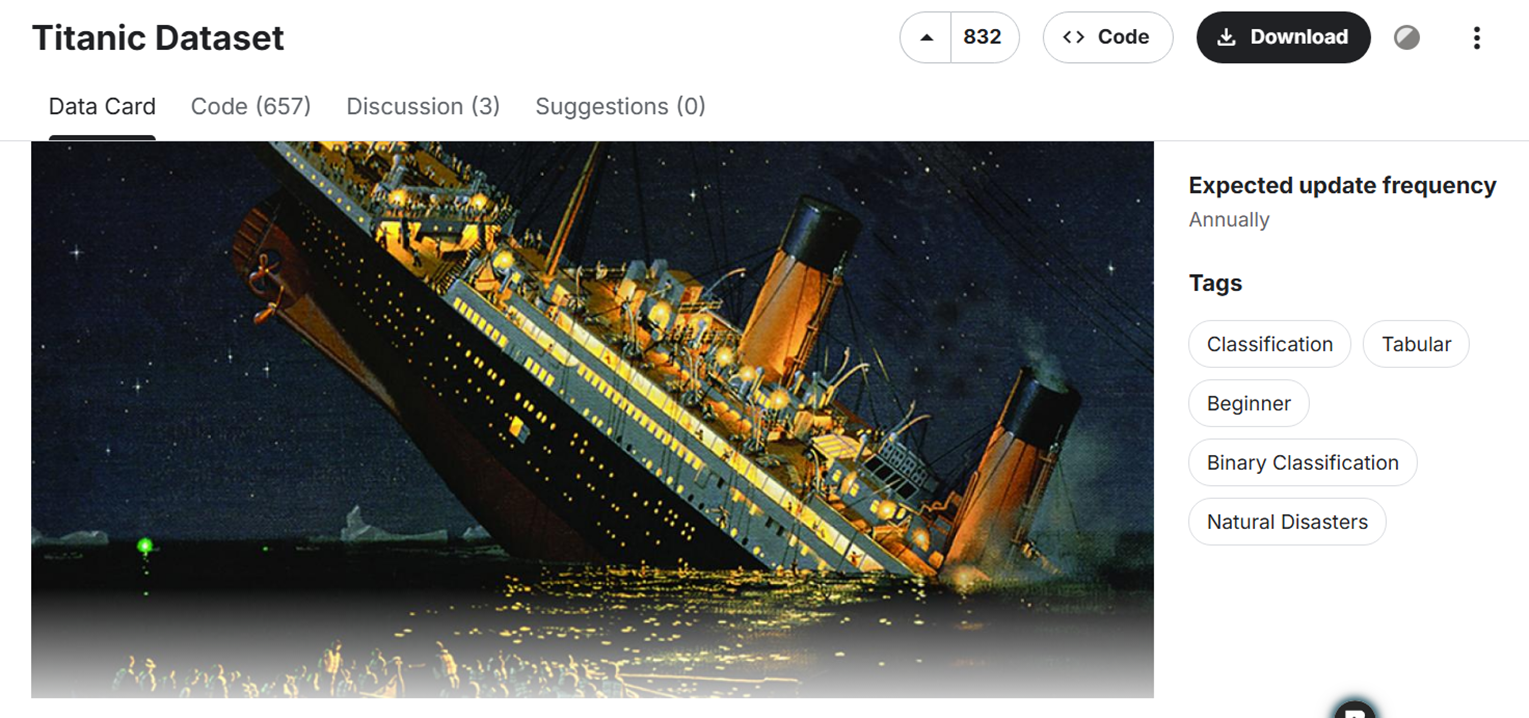

El hundimiento del Titanic es uno de los naufragios más tristemente célebres de la historia.

El 15 de abril de 1912, durante su viaje inaugural, el RMS Titanic, considerado por muchos «insumergible», se hundió tras colisionar con un iceberg. Desgraciadamente, no había suficientes botes salvavidas para todos los que iban a bordo, lo que provocó la muerte de 1502 de los 2224 pasajeros y tripulantes.

Aunque la supervivencia dependió en parte de la suerte, parece que algunos grupos de personas tenían más probabilidades de sobrevivir que otros.




In [ ]:
df_orig = pd.read_csv('/content/Titanic-Dataset.csv')

## 2. Funciones básicas de visualización de datos

* El proceso de visualización siempre debe realizarse en el conjunto de entrenamiento y lejos del conjunto de prueba. Esto evita que nuestro cerebro genere intuiciones sobre el conjunto de prueba que podamos incorporar a nuestro modelo.
* Una buena práctica es crear una copia del conjunto de entrenamiento y jugar con ella. De esta manera, si realizamos transformaciones que dañan el conjunto de entrenamiento, el original no se ve afectado.

In [ ]:
df = df_orig.copy()

In [ ]:
# Mostrar un número determinado de filas en la pantalla.
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
# Mostrar información básica sobre el conjunto de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Mostrar información estadística sobre el conjunto de datos.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [ ]:
# Mostrar los valores únicos de un atributo determinado.
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


Los algoritmos de aprendizaje automático no pueden trabajar con características que contengan valores nulos. Por lo tanto, hay tres opciones para sustituirlos:
* Eliminar las filas correspondientes
*   Eliminar el atributo correspondiente
*   Rellenarlos con un valor determinado (cero, media...)


In [ ]:
# Comprobamos si hay algún atributo con valores nulos.
df.isna().any()

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Sex,False
Age,True
SibSp,False
Parch,False
Ticket,False
Fare,False


# 3. División del conjunto de datos

El conjunto de datos debe dividirse en los diferentes subconjuntos necesarios para llevar a cabo los procesos de entrenamiento, validación y prueba.

In [ ]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


Este parámetro stratify realiza una división para que la proporción de valores en la muestra producida sea la misma que la proporción de valores proporcionados al parámetro stratify.

Por ejemplo, si la variable y es una variable categórica binaria con valores 0 y 1 y hay un 25 % de ceros y un 75 % de unos, stratify=y se asegurará de que la división aleatoria tenga un 25 % de 0 y un 75 % de 1.

https://stackoverflow.com/a/38889389



In [ ]:
# Construcción de una función que realiza la partición completa.
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [ ]:
# Dividimos el conjunto de datos.
train_set, val_set, test_set = train_val_test_split(df, stratify='Survived')

In [ ]:
X_train, y_train = remove_labels(train_set, 'Survived')
X_val, y_val = remove_labels(val_set, 'Survived')
X_test, y_test = remove_labels(test_set, 'Survived')

# 4. Preparación de los datos

ColumnTransformer permite aplicar diferentes transformaciones a diferentes tipos de columnas de forma ordenada, reproducible y sin fuga de información.

1️⃣ **Entrada:** Partimos de un DataFrame con columnas mixtas.

2️⃣ **ColumnTransformer:** ColumnTransformer separa las columnas y las envía al pipeline correcto.

3️⃣ **Dos flujos en paralelo:**
Numérico → imputación + escalamiento
Categórico → imputación + one-hot

4️⃣ **Salida única:** Al final todo se concatena en una sola matriz numérica lista para el modelo.

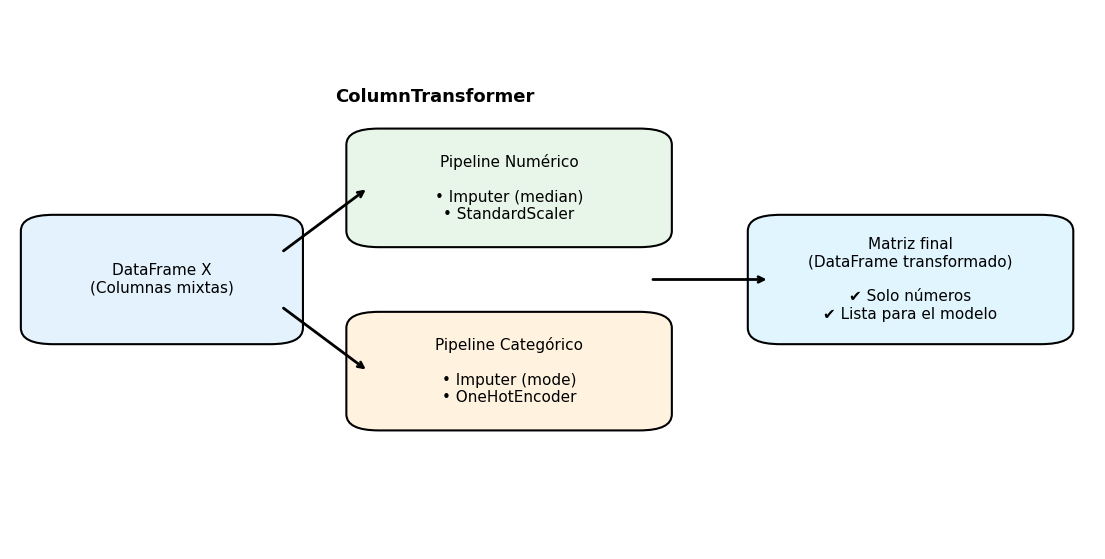

In [ ]:
class DataFramePreparer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.numeric_features_ = None
        self.categorical_features_ = None
        self.preprocess_ = None
        self.feature_names_ = None

    def fit(self, X, y=None):
        # Selección automática
        self.numeric_features_ = X.select_dtypes(exclude=["object"]).columns
        self.categorical_features_ = X.select_dtypes(include=["object"]).columns

        numeric_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ])

        self.preprocess_ = ColumnTransformer(
            transformers=[
                ("num", numeric_pipeline, self.numeric_features_),
                ("cat", categorical_pipeline, self.categorical_features_)
            ]
        )

        self.preprocess_.fit(X)

        # Construcción de nombres finales de columnas
        num_features = self.numeric_features_
        cat_features = self.preprocess_ \
            .named_transformers_["cat"] \
            .named_steps["onehot"] \
            .get_feature_names_out(self.categorical_features_)

        self.feature_names_ = list(num_features) + list(cat_features)

        return self

    def transform(self, X):
        X_transformed = self.preprocess_.transform(X)
        return pd.DataFrame(
            X_transformed,
            columns=self.feature_names_,
            index=X.index
        )


In [ ]:
prep = DataFramePreparer()
prep.fit(X_train)

X_train_prep = prep.transform(X_train)
X_val_prep = prep.transform(X_val)
X_test_prep = prep.transform(X_test)

In [ ]:
X_train_prep.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
844,0.819472,-1.009092,-0.479956,-0.458433,-0.463691,0.0,1.0,0.0,0.0,1.0
316,-0.379427,-0.470634,0.620028,-0.458433,-0.114701,1.0,0.0,0.0,0.0,1.0
768,0.819472,-0.086022,0.620028,-0.458433,-0.151940,0.0,1.0,0.0,1.0,0.0
255,0.819472,-0.086022,-0.479956,1.965362,-0.331174,1.0,0.0,1.0,0.0,0.0
130,0.819472,0.221668,-0.479956,-0.458433,-0.479124,0.0,1.0,1.0,0.0,0.0


# 5. Entrenamiento del modelo mediante Hyperband

In [ ]:
# Configuración de recursos (rungs)
MIN_TREES = 50
MAX_TREES = 300
STEP_TREES = 50
REDUCTION = 3

pruner = optuna.pruners.HyperbandPruner(
    min_resource=MIN_TREES,
    max_resource=MAX_TREES,
    reduction_factor=REDUCTION
)

sampler = optuna.samplers.TPESampler(seed=42)

In [ ]:
def objective(trial: optuna.trial.Trial) -> float:
    max_depth = trial.suggest_int("max_depth", 3, 20)

    rf = RandomForestClassifier(
        n_estimators=0,
        max_depth=max_depth,
        bootstrap=True,
        random_state=42,
        n_jobs=-1,
        warm_start=True
    )

    best_acc = -np.inf
    best_n_trees = MIN_TREES

    for n_trees in range(MIN_TREES, MAX_TREES + 1, STEP_TREES):
        rf.n_estimators = n_trees
        rf.fit(X_train_prep, y_train)

        y_pred_val = rf.predict(X_val_prep)
        acc = accuracy_score(y_val, y_pred_val)

        trial.report(acc, step=n_trees)

        if acc > best_acc:
            best_acc = acc
            best_n_trees = n_trees

        if trial.should_prune():
            raise optuna.TrialPruned()

    # 🔹 Guardamos el mejor número de árboles en el trial
    trial.set_user_attr("best_n_estimators", best_n_trees)

    return best_acc
# Study
study_name = "rf_hyperband_titanic_optuna_acc"
storage = None

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    study_name=study_name,
    storage=storage
)

N_TRIALS = 30
start_time = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
elapsed = time.time() - start_time

print("\n===== RESULTADOS HYPERBAND (Optuna) =====")
print(f"Trials ejecutados: {len(study.trials)}")
print(f"Mejor valor (Accuracy val): {study.best_value:.5f}")

best_trial = study.best_trial
best_max_depth = best_trial.params["max_depth"]
best_n_estimators = best_trial.user_attrs["best_n_estimators"]

print("Mejor accuracy:", best_trial.value)
print("Mejor max_depth:", best_max_depth)
print("Mejor número de árboles:", best_n_estimators)

[I 2026-02-06 14:56:58,989] A new study created in memory with name: rf_hyperband_titanic_optuna_acc
[I 2026-02-06 14:57:00,234] Trial 0 finished with value: 0.848314606741573 and parameters: {'max_depth': 9}. Best is trial 0 with value: 0.848314606741573.
[I 2026-02-06 14:57:02,380] Trial 1 finished with value: 0.8089887640449438 and parameters: {'max_depth': 20}. Best is trial 0 with value: 0.848314606741573.
[I 2026-02-06 14:57:04,446] Trial 2 finished with value: 0.8146067415730337 and parameters: {'max_depth': 16}. Best is trial 0 with value: 0.848314606741573.
[I 2026-02-06 14:57:05,635] Trial 3 pruned. 
[I 2026-02-06 14:57:08,800] Trial 4 finished with value: 0.8370786516853933 and parameters: {'max_depth': 5}. Best is trial 0 with value: 0.848314606741573.
[I 2026-02-06 14:57:09,941] Trial 5 pruned. 
[I 2026-02-06 14:57:11,134] Trial 6 pruned. 
[I 2026-02-06 14:57:11,456] Trial 7 pruned. 
[I 2026-02-06 14:57:11,784] Trial 8 pruned. 
[I 2026-02-06 14:57:12,149] Trial 9 pruned. 



===== RESULTADOS HYPERBAND (Optuna) =====
Trials ejecutados: 30
Mejor valor (Accuracy val): 0.85393
Mejor accuracy: 0.8539325842696629
Mejor max_depth: 8
Mejor número de árboles: 150


In [ ]:
# Entrenar el modelo final con el recurso máximo
best_rf = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_prep, y_train)

RandomForestClassifier(max_depth=8, n_estimators=150, n_jobs=-1,
                       random_state=42)

In [ ]:
# Métricas en validación
y_pred_val_best = best_rf.predict(X_val_prep)
y_pred_val_proba = best_rf.predict_proba(X_val_prep)[:, 1]

acc_val = accuracy_score(y_val, y_pred_val_best)
auc_val = roc_auc_score(y_val, y_pred_val_proba)

print("\n===== MÉTRICAS VALIDACIÓN =====")
print(f"Accuracy: {acc_val:.4f}")
print(f"AUC: {auc_val:.4f}")


===== MÉTRICAS VALIDACIÓN =====
Accuracy: 0.8539
AUC: 0.8648


## 📌 Tarea propuesta: Optimización Bayesiana (Multiobjetivo)

### 🎯 Objetivo  
Comprender qué es la **optimización bayesiana** y aplicar **optimización multiobjetivo** para el ajuste de hiperparámetros, considerando criterios de **producción** (no solo accuracy).

### 📖 Parte 1: Investigación  
Investigue:
- ¿Qué es la optimización bayesiana?
- Diferencias con Grid Search y Random Search
- ¿Qué es un *surrogate model* y una *función de adquisición*?
- ¿Qué es optimización **multiobjetivo** y por qué importa en producción?

**Lectura sugerida:**  
Onorato, G. (2024). Bayesian optimization for hyperparameters tuning in neural networks. arXiv preprint arXiv:2410.21886.

### 🧪 Parte 2: Laboratorio  
1. Seleccione un modelo (Random Forest, SVM o similar).  
2. Defina un espacio de hiperparámetros.  
3. **Modifique el `ColumnTransformer`** para reemplazar `OneHotEncoder` por **otra técnica** de codificación categórica (por ejemplo: `OrdinalEncoder` o `FeatureHasher`).  
   - Explique brevemente **por qué** eligió esa técnica (ventajas/desventajas frente a OneHot).  
4. Aplique **Optimización Bayesiana Multiobjetivo**.  
5. Optimice **≥2 objetivos**, por ejemplo:  
   - Maximizar desempeño (accuracy/F1/AUC)  
   - Minimizar criterio de producción (latencia de inferencia, tiempo de entrenamiento o complejidad del modelo)  
6. Analice el **trade-off** (frontera de Pareto) y concluya.

### 📦 Entregable  
Un **Jupyter Notebook** con: resumen breve (Markdown), implementación (incluyendo el cambio de codificación), análisis del trade-off y conclusiones.  
*(No se requiere informe adicional.)*

> 💡 En escenarios reales no optimizamos solo accuracy: también optimizamos costo, tiempo y eficiencia en producción.

### 📐 Rúbrica de evaluación (10 pts)

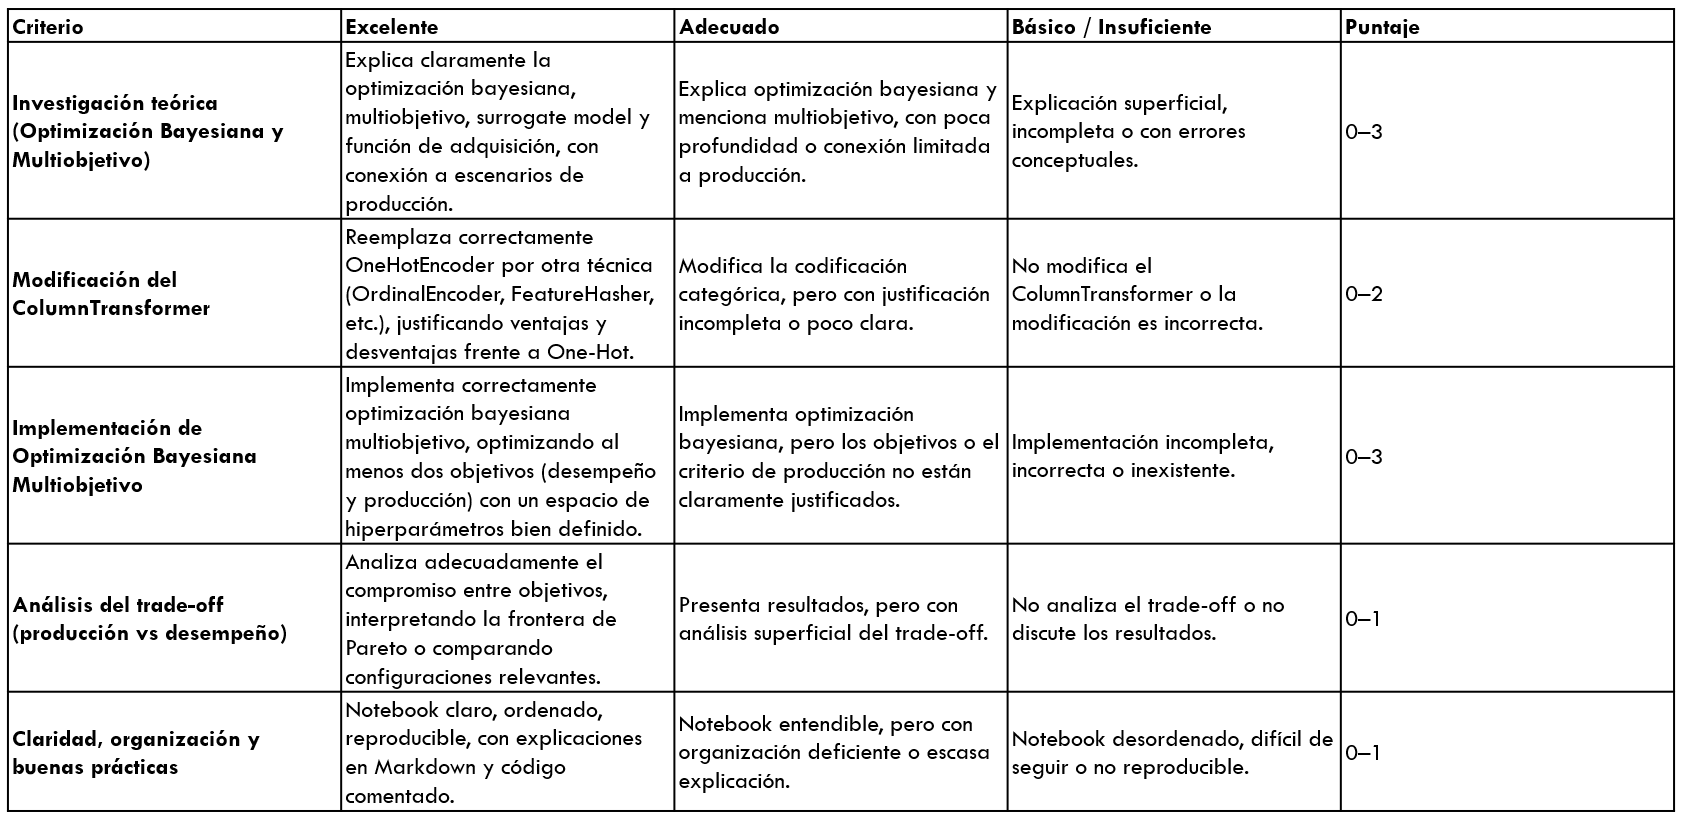
